Анализ акций американского рынка: сравнение моделей CAPM и Фамы-Френча

In [1]:
# Общие импорты
import numpy as np
import pandas as pd
import statsmodels.api as sm
import matplotlib.pyplot as plt

1. Предобработка данных

In [2]:
# Загрузка доходностей и цен

returns = pd.read_csv(
    "monthly_returns_2013-2024.csv",
    parse_dates=["Date"]
)

close = pd.read_csv(
    "monthly_close_2013-2024_cleaned_with_benchmarks.csv",
    parse_dates=["Date"]
)

returns.set_index("Date", inplace=True)
close.set_index("Date", inplace=True)

# Тикеры акций (без индекса и безрисковой ставки)
drop_cols = ["^GSPC", "^IRX_monthly"]
stock_tickers = [c for c in returns.columns if c not in drop_cols]

print(f"Всего акций в панели: {len(stock_tickers)}")

Всего акций в панели: 457


In [3]:
# Полный горизонт по доходностям
full_start = returns.index.min()
full_end = returns.index.max()

mask_full = (returns.index >= full_start) & (returns.index <= full_end)

In [4]:
def describe_panel(panel: pd.DataFrame) -> dict:
    """Простая описательная статистика по панельным доходностям."""
    vals = panel.values.flatten()
    vals = vals[~np.isnan(vals)]
    return {
        "n_months": panel.shape[0],
        "n_stocks": panel.shape[1],
        "mean_monthly_return": float(np.mean(vals)),
        "std_monthly_return": float(np.std(vals, ddof=1)),
        "min_monthly_return": float(np.min(vals)),
        "max_monthly_return": float(np.max(vals)),
    }

In [5]:
panel_full = returns.loc[mask_full, stock_tickers]
desc_full = describe_panel(panel_full)

In [6]:
print("\n=== Описательные статистики: 11 лет (2013–2024) ===")
for k, v in desc_full.items():
    if isinstance(v, float):
        print(f"{k}: {v:.6f}")
    else:
        print(f"{k}: {v}")


=== Описательные статистики: 11 лет (2013–2024) ===
n_months: 143
n_stocks: 457
mean_monthly_return: 0.012291
std_monthly_return: 0.082286
min_monthly_return: -0.803197
max_monthly_return: 1.124158


In [7]:
# Индекс S&P 500 для справки
gspc_full = returns.loc[mask_full, "^GSPC"]

print("\n=== Индекс S&P 500 (^GSPC), 11 лет (2013–2024) ===")
print(gspc_full.describe())


=== Индекс S&P 500 (^GSPC), 11 лет (2013–2024) ===
count    143.000000
mean       0.010504
std        0.041617
min       -0.125119
25%       -0.015040
50%        0.017859
75%        0.035331
max        0.126844
Name: ^GSPC, dtype: float64


2. Конструирование факторов Фамы-Френча (MKT, SMB, HML)

In [8]:
# Загрузка и чистка Market Value и Book Value

# Market Value по годам. Предполагаем формат:
# строка = тикер, столбцы = даты (например, 2013-12-31, 2014-12-31, ...)
mv_pivot = pd.read_csv("historical_market_cap_pivot.csv")

# Чистим MV: заменяем нули и отрицательные значения на NaN
mv_cols = [c for c in mv_pivot.columns if c != "Ticker"]
mv_pivot[mv_cols] = mv_pivot[mv_cols].where(mv_pivot[mv_cols] > 0, np.nan)

# Приводим MV к формату (Ticker, Year, MV)
mv_long = mv_pivot.melt(
    id_vars="Ticker",
    var_name="date",
    value_name="MV"
)
mv_long["Year"] = pd.to_datetime(mv_long["date"]).dt.year
mv_long = mv_long[["Ticker", "Year", "MV"]]

# Book Value по годам из Alpha Vantage.
# Формат ожидается: Year, Ticker1, Ticker2, ...
bv_pivot = pd.read_csv("book_value_alpha_vantage_full.csv")

if "Year" not in bv_pivot.columns:
    bv_pivot = bv_pivot.rename(columns={"Unnamed: 0": "Year"})

bv_pivot = bv_pivot.sort_values("Year")

bv_cols = [c for c in bv_pivot.columns if c != "Year"]
# Заменяем нули и отрицательные значения на NaN (фирма не в выборке или отрицательный equity)
bv_pivot[bv_cols] = bv_pivot[bv_cols].where(bv_pivot[bv_cols] > 0, np.nan)

# Приводим BV к формату (Year, Ticker, BE)
bv_long = bv_pivot.melt(
    id_vars="Year",
    var_name="Ticker",
    value_name="BE"
)

# Объединяем MV и BV и считаем B/M
fundamentals = mv_long.merge(bv_long, on=["Ticker", "Year"], how="inner")
fundamentals = fundamentals.dropna(subset=["MV", "BE"])

fundamentals["BM"] = fundamentals["BE"] / fundamentals["MV"]

# Убираем наблюдения с неадекватным B/M (на всякий случай)
fundamentals = fundamentals[fundamentals["BM"] > 0].copy()


In [9]:
# Определяем годы формирования портфелей t (lag t -> t+1)

years_bv = sorted(fundamentals["Year"].unique())
years_returns = sorted(returns.index.year.unique())

formation_years = []
for y in years_bv:
    if (y + 1) in years_returns:
        formation_years.append(y)

print("\nГоды формирования портфелей (t):", formation_years)
print("Портфели будут держаться в (t+1):", [y + 1 for y in formation_years])


Годы формирования портфелей (t): [np.int32(2013), np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023)]
Портфели будут держаться в (t+1): [np.int32(2014), np.int32(2015), np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021), np.int32(2022), np.int32(2023), np.int32(2024)]


In [10]:
# Формируем 6 портфелей FF на каждый год t (S/L, S/M, S/H, B/L, B/M, B/H)

memberships = {}  # {hold_year: {"SL": [tickers], ...}}

for t in formation_years:
    hold_year = t + 1

    df_t = fundamentals[fundamentals["Year"] == t].copy()

    # Ограничиваемся тикерами, которые есть в доходностях
    df_t = df_t[df_t["Ticker"].isin(stock_tickers)]

    if df_t.empty:
        continue

    # Разрез по размеру: медиана MV
    size_median = df_t["MV"].median()
    df_t["Size"] = np.where(df_t["MV"] <= size_median, "S", "B")

    # Разрез по B/M: 30 и 70 перцентили
    p30 = np.nanpercentile(df_t["BM"], 30)
    p70 = np.nanpercentile(df_t["BM"], 70)

    def assign_bm_group(bm_value: float) -> str:
        if bm_value <= p30:
            return "L"
        elif bm_value <= p70:
            return "M"
        else:
            return "H"

    df_t["BM_group"] = df_t["BM"].apply(assign_bm_group)

    mem = {}
    for size in ["S", "B"]:
        for bm_g in ["L", "M", "H"]:
            label = f"{size}{bm_g}"
            tickers_list = df_t[
                (df_t["Size"] == size) & (df_t["BM_group"] == bm_g)
            ]["Ticker"].tolist()
            mem[label] = tickers_list

    memberships[hold_year] = mem


In [11]:
# Считаем доходности 6 портфелей (equal-weight) по месяцам

ff_ports = pd.DataFrame(
    index=returns.index,
    columns=["SL", "SM", "SH", "BL", "BM", "BH"],
    dtype=float
)

for hold_year, mem in memberships.items():
    year_mask = returns.index.year == hold_year
    for label, tickers_list in mem.items():
        if len(tickers_list) == 0:
            continue
        # equal-weight доходность портфеля
        ff_ports.loc[year_mask, label] = returns.loc[year_mask, tickers_list].mean(axis=1)

ff_ports = ff_ports.dropna()

print("\nFF-портфели существуют с", ff_ports.index.min().date(), "по", ff_ports.index.max().date())


FF-портфели существуют с 2014-01-31 по 2024-12-31


In [12]:
# Строим факторы SMB, HML и рыночный фактор

factors = pd.DataFrame(index=returns.index)

# SMB: среднее по маленьким минус среднее по большим
factors["SMB"] = (
    ff_ports[["SL", "SM", "SH"]].mean(axis=1)
    - ff_ports[["BL", "BM", "BH"]].mean(axis=1)
)

# HML: среднее high B/M минус среднее low B/M
factors["HML"] = (
    ff_ports[["SH", "BH"]].mean(axis=1)
    - ff_ports[["SL", "BL"]].mean(axis=1)
)

# Рыночный фактор и безрисковая ставка
factors["MKT_excess"] = returns["^GSPC"] - returns["^IRX_monthly"]
factors["RF"] = returns["^IRX_monthly"]

# Оставляем месяцы, где SMB и HML определены
factors = factors.dropna()

print("\nФакторы FF доступны с", factors.index.min().date(), "по", factors.index.max().date())


Факторы FF доступны с 2014-01-31 по 2024-12-31


In [13]:
# Даты, на которых будем строить модели
analysis_dates = factors.index

3. Оценка модели CAPM

In [14]:
rf = factors["RF"]
mkt_excess = factors["MKT_excess"]

# Избыточные доходности акций
asset_excess = returns.loc[analysis_dates, stock_tickers].subtract(rf, axis=0)


def run_ts_regression(y: pd.Series, X: pd.DataFrame) -> dict:
    """Универсальная функция для time-series регрессии y_t = alpha + beta' X_t + eps_t."""
    X_const = sm.add_constant(X)
    model = sm.OLS(y, X_const, missing="drop").fit()
    result = {
        "alpha": model.params["const"],
        "t_alpha": model.tvalues["const"],
        "R2": model.rsquared,
        "n_obs": int(model.nobs),
    }
    for name in X.columns:
        result[f"beta_{name}"] = model.params[name]
        result[f"t_{name}"] = model.tvalues[name]
    return result

In [15]:
# CAPM: R_i - R_f = alpha_i + beta_i * MKT_excess + eps_i
capm_results = {}
for ticker in stock_tickers:
    y = asset_excess[ticker]
    X = factors[["MKT_excess"]]
    capm_results[ticker] = run_ts_regression(y, X)

capm_df = pd.DataFrame(capm_results).T

print("\nПример результатов CAPM:")
print(capm_df.head())


Пример результатов CAPM:
         alpha   t_alpha        R2  n_obs  beta_MKT_excess  t_MKT_excess
A     0.000328  0.075668  0.507231  132.0         1.155896     11.567845
AAPL  0.010568  2.064713  0.460440  132.0         1.243968     10.532676
ABBV  0.004440  0.749253  0.174609  132.0         0.717111      5.244147
ABT   0.001316  0.339413  0.408757  132.0         0.848425      9.480285
ACGL  0.007239  1.304649  0.163866  132.0         0.646274      5.047522


У всех приведённых бумаг (A, AAPL, ABBV, ABT, ACGL) бета по рыночному фактору положительная и статистически высоко значима: t-статистики по β_MKT намного больше 2. Это значит, что избыточные доходности этих акций в значительной степени движутся вместе с рынком, и простой CAPM действительно ловит основную динамику доходностей.

При этом качество подгонки модели отличается по бумагам. Для A, AAPL и ABT коэффициент детерминации R² находится на уровне около 0,46–0,51, то есть рыночный фактор объясняет примерно половину вариации их избыточных доходностей. Для ABBV и ACGL R² заметно ниже, порядка 0,16–0,17, что говорит о более сильной роли фирменно-специфических шоков и менее «рыночном» характере этих акций.

Альфы также ведут себя предсказуемо. Для A, ABBV, ABT и ACGL t-статистики по α меньше 2, поэтому их альфы статистически не отличимы от нуля, и на горизонте 2014–2024 гг. они не демонстрируют устойчивой сверхдоходности относительно CAPM. Исключением является AAPL: оценочная альфа около 1,06% в месяц с t≈2,06 формально значима на 5%-ном уровне. Это можно интерпретировать как то, что за рассматриваемый период акции Apple в среднем переигрывали предсказания классического CAPM, даже после учёта рыночного риска.

4. Модель Фама-Френч (3 фактора) + процедура Фама-Макбет

In [16]:
# Time-series регрессии FF3

ff3_results = {}
for ticker in stock_tickers:
    y = asset_excess[ticker]
    X = factors[["MKT_excess", "SMB", "HML"]]
    ff3_results[ticker] = run_ts_regression(y, X)

ff3_df = pd.DataFrame(ff3_results).T

# Выделяем беты для Фама–Макбет
ff3_betas = ff3_df[["beta_MKT_excess", "beta_SMB", "beta_HML"]].rename(
    columns={"beta_MKT_excess": "beta_MKT"}
)

print("\nПример результатов FF3:")
print(ff3_df.head())


Пример результатов FF3:
         alpha   t_alpha        R2  n_obs  beta_MKT_excess  t_MKT_excess  \
A    -0.003547 -0.773627  0.527467  132.0         1.104718     10.866510   
AAPL  0.006814  1.292926  0.510628  132.0         1.243451     10.640381   
ABBV  0.007068  1.108605  0.182916  132.0         0.751596      5.317027   
ABT  -0.001119 -0.274082  0.439296  132.0         0.842348      9.302829   
ACGL  0.012188  2.139482  0.246202  132.0         0.660885      5.232354   

      beta_SMB     t_SMB  beta_HML     t_HML  
A     0.843569  2.122692 -0.202899 -1.361262  
AAPL  0.091590  0.200494 -0.615567 -3.592746  
ABBV -0.568789 -1.029350  0.139413  0.672682  
ABT   0.144339  0.407790 -0.350371 -2.639209  
ACGL -0.326740 -0.661761  0.692414  3.739041  


В трёхфакторной модели Фама Френч качество подгонки по всем пяти акциям улучшается: R2 растет по сравнению с CAPM, а большинство альф теряют статистическую значимость. У AAPL альфа уменьшается и становится незначимой, то есть сверхдоходность почти исчезает после учета факторов размера и стоимости. Для ACGL, напротив, сохраняется положительная и значимая альфа, что являются редким наблюдением. Нагрузки на SMB и HML выглядят экономически логично: одни бумаги ведут себя скорее как growth (отрицательные beta_HML), другие ближе к value (положительные beta_HML), что подтверждает корректность работы трехфакторной модели.

In [17]:
# ДОПОЛНИТЕЛЬНО: VALUE WEIGHTED FF-ПОРТФЕЛИ И ФАКТОРЫ
# 1) Value weighted доходности 6 FF-портфелей

ff_ports_vw = pd.DataFrame(
    index=returns.index,
    columns=["SL", "SM", "SH", "BL", "BM", "BH"],
    dtype=float
)

for hold_year, mem in memberships.items():
    year_t = hold_year - 1  # год формирования портфеля
    df_t = fundamentals[fundamentals["Year"] == year_t].copy()
    # оставляем только тикеры, входящие в наши портфели
    df_t = df_t[df_t["Ticker"].isin(sum(mem.values(), []))]

    for label, tickers_list in mem.items():
        if len(tickers_list) == 0:
            continue

        # MV на конец года t для тикеров портфеля
        df_port = df_t[df_t["Ticker"].isin(tickers_list)].copy()
        if df_port.empty:
            continue

        mv_vec = df_port.set_index("Ticker")["MV"].dropna()
        if mv_vec.empty:
            continue

        weights = mv_vec / mv_vec.sum()  # веса по капитализации

        # месячные доходности этих тикеров в hold_year
        year_mask = returns.index.year == hold_year
        ret_panel = returns.loc[year_mask, weights.index]

        # value weighted доходность портфеля
        ff_ports_vw.loc[ret_panel.index, label] = (ret_panel * weights).sum(axis=1)

# выкидываем месяцы, где нет данных по всем 6 портфелям
ff_ports_vw = ff_ports_vw.dropna()

print("\nValue weighted FF-портфели существуют с",
      ff_ports_vw.index.min().date(), "по", ff_ports_vw.index.max().date())
# 2Строим value-weighted факторы SMB_vw, HML_vw и рыночный фактор

factors_vw = pd.DataFrame(index=returns.index)

# SMB_vw: среднее по маленьким минус среднее по большим
factors_vw["SMB_vw"] = (
    ff_ports_vw[["SL", "SM", "SH"]].mean(axis=1)
    - ff_ports_vw[["BL", "BM", "BH"]].mean(axis=1)
)

# HML_vw: среднее high B/M минус среднее low B/M
factors_vw["HML_vw"] = (
    ff_ports_vw[["SH", "BH"]].mean(axis=1)
    - ff_ports_vw[["SL", "BL"]].mean(axis=1)
)

# Рыночный фактор и безрисковая ставка
factors_vw["MKT_excess"] = returns["^GSPC"] - returns["^IRX_monthly"]
factors_vw["RF"] = returns["^IRX_monthly"]

# Оставляем месяцы, где SMB_vw и HML_vw определены
factors_vw = factors_vw.dropna()

print("\nValue weighted факторы FF доступны с", factors_vw.index.min().date(), "по", factors_vw.index.max().date())


Value weighted FF-портфели существуют с 2014-01-31 по 2024-12-31

Value weighted факторы FF доступны с 2014-01-31 по 2024-12-31


In [18]:
ff3_vw_results = {}
for ticker in stock_tickers:
    y = returns.loc[factors_vw.index, ticker] - factors_vw["RF"]
    X = factors_vw[["MKT_excess", "SMB_vw", "HML_vw"]]
    ff3_vw_results[ticker] = run_ts_regression(y, X)

ff3_vw_df = pd.DataFrame(ff3_vw_results).T

print("\nПример результатов FF3 (value weighted факторы):")
print(ff3_vw_df.head())


Пример результатов FF3 (value weighted факторы):
         alpha   t_alpha        R2  n_obs  beta_MKT_excess  t_MKT_excess  \
A    -0.002040 -0.481671  0.557793  132.0         1.094692     11.314077   
AAPL  0.007551  1.552238  0.542641  132.0         1.273287     11.455948   
ABBV  0.005309  0.870292  0.179228  132.0         0.715359      5.132337   
ABT  -0.000678 -0.172888  0.433437  132.0         0.831715      9.288073   
ACGL  0.010617  1.976276  0.264616  132.0         0.628421      5.120089   

      beta_SMB_vw  t_SMB_vw  beta_HML_vw  t_HML_vw  
A        1.106930  3.805311    -0.273227 -2.022633  
AAPL    -0.464235 -1.389268    -0.545751 -3.516949  
ABBV     0.016796  0.040081     0.144861  0.744403  
ABT      0.323642  1.202151    -0.294261 -2.353693  
ACGL     0.258200  0.699722     0.583310  3.404030  


В версии модели с value weighted факторами общая картина по отдельным акциям не меняется: рыночные беты остаются высокими и хорошо значимыми, альфы в большинстве случаев статистически не отличаются от нуля. Нагрузки на факторы размера и стоимости становятся ещё более «чистыми»: акция A выглядит как небольшая growth компания (высокая beta_SMB_vw и отрицательная beta_HML_vw), AAPL — крупная growth, а ACGL получает ярко выраженную value нагрузку. Это говорит о том, что переход к value weighted факторам уточняет структуру β, но не даёт принципиально новых аномалий по доходностям и подтверждает устойчивость выводов, сделанных на равновзвешенных факторах.

In [19]:
# Даты анализа для Фама–Макбет теперь берём из value weighted факторов
analysis_dates = factors_vw.index

# Избыточные доходности акций считаем с RF из value weighted факторов
asset_excess = returns.loc[analysis_dates, stock_tickers].subtract(factors_vw["RF"], axis=0)

# Беты для Фама–Макбет берём из FF3 с value weighted факторами
ff3_betas = ff3_vw_df[["beta_MKT_excess", "beta_SMB_vw", "beta_HML_vw"]].rename(
    columns={
        "beta_MKT_excess": "beta_MKT",
        "beta_SMB_vw": "beta_SMB",
        "beta_HML_vw": "beta_HML"
    }
)

In [20]:
# Процедура Фама–Макбет: оценка факторных премий lambda

lambdas_list = []

for t in analysis_dates:
    y_t = asset_excess.loc[t]

    X_t = ff3_betas.loc[y_t.index, ["beta_MKT", "beta_SMB", "beta_HML"]]
    X_t_const = sm.add_constant(X_t)

    model_cs = sm.OLS(y_t.values, X_t_const.values).fit()

    lambdas_list.append({
        "Date": t,
        "lambda_0": model_cs.params[0],
        "lambda_MKT": model_cs.params[1],
        "lambda_SMB": model_cs.params[2],
        "lambda_HML": model_cs.params[3],
    })

lambdas_df = pd.DataFrame(lambdas_list).set_index("Date")

T = lambdas_df.shape[0]
lambda_means = lambdas_df.mean()
lambda_se = lambdas_df.std(ddof=1) / np.sqrt(T)
lambda_t = lambda_means / lambda_se

lambda_summary = pd.DataFrame({
    "mean_lambda": lambda_means,
    "t_stat": lambda_t
})

print("\nФама–Макбет: средние премии факторов и t-статистики")
print(lambda_summary)



Фама–Макбет: средние премии факторов и t-статистики
            mean_lambda    t_stat
lambda_0       0.002571  0.794870
lambda_MKT     0.009852  2.001507
lambda_SMB    -0.002377 -1.550753
lambda_HML    -0.008113 -2.558593


Фама–Макбет с value-weighted факторами подтверждает ключевые выводы. Премия за рыночный риск остаётся положительной и значимой, что согласуется с классическими представлениями о доходности рынка. Премия за фактор размера по модулю близка к нулю и статистически не подтверждается, то есть small-кап эффект в выборке отсутствует. Премия за фактор стоимости уверенно отрицательная и значима, что означает устойчивое доминирование growth компаний над value на протяжении анализируемого периода.

Дополнительно выполнена Ньюи Уэста для оценок Фама Макбет. Расчет t статистик с поправкой на автокорреляцию во времени делает выводы формально более строгими и показывает, что ключевые результаты по премиям факторов сохраняются даже при более жесткой проверке. 

In [21]:
# ДОПОЛНИТЕЛЬНО: ФАМА МАКБЕТ С ПОПРАВКОЙ НА АВТОКОРРЕЛЯЦИЮ (NEWEY WEST)
from statsmodels.stats.sandwich_covariance import cov_hac

# строим регрессию lambda_t на константу с HAC ковариацией
lambda_hac_results = []

max_lag = 3  # число лагов для поправки на автокорреляцию, можно взять 3 или 4

for col in ["lambda_0", "lambda_MKT", "lambda_SMB", "lambda_HML"]:
    y = lambdas_df[col].values
    X = np.ones((len(y), 1))  # регрессия на константу

    model = sm.OLS(y, X).fit(cov_type="HAC", cov_kwds={"maxlags": max_lag})

    mean_lambda = model.params[0]
    se_hac = model.bse[0]
    t_hac = mean_lambda / se_hac

    lambda_hac_results.append({
        "factor": col,
        "mean_lambda": mean_lambda,
        "se_HAC": se_hac,
        "t_HAC": t_hac
    })

lambda_summary_hac = pd.DataFrame(lambda_hac_results).set_index("factor")

print("\nФама Макбет с поправкой Newey West (HAC):")
print(lambda_summary_hac)


Фама Макбет с поправкой Newey West (HAC):
            mean_lambda    se_HAC     t_HAC
factor                                     
lambda_0       0.002571  0.003019  0.851585
lambda_MKT     0.009852  0.004586  2.148085
lambda_SMB    -0.002377  0.001343 -1.770249
lambda_HML    -0.008113  0.003575 -2.269081


5. Сравнение моделей CAPM и Фама-Макбет

In [22]:
alpha_t_crit = 1.96

In [23]:
# CAPM: статистика по альфам
capm_df["alpha_sig"] = capm_df["t_alpha"].abs() > alpha_t_crit

print("\nКоличество значимых альф CAPM (|t_alpha| > 1.96):")
print(f"CAPM: {capm_df['alpha_sig'].sum()} из {capm_df.shape[0]}")
print(f"Доля акций с значимой альфой CAPM: {capm_df['alpha_sig'].mean():.3f}")


Количество значимых альф CAPM (|t_alpha| > 1.96):
CAPM: 28 из 457
Доля акций с значимой альфой CAPM: 0.061


Лишь небольшая часть акций показывает статистически значимую альфу в CAPM: около шести процентов выборки. Это означает, что для подавляющего числа бумаг отклонения от предсказаний модели неустойчивы и не свидетельствуют о постоянной сверхдоходности. Такие результаты согласуются с тем, что рыночный фактор объясняет основную часть динамики доходностей, а оставшиеся колебания являются случайным шумом.

/var/folders/4g/z_1x55j17vn7631j_l1gtqyc0000gn/T/ipykernel_54525/3652986365.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([capm_df["alpha"]], labels=["CAPM"])


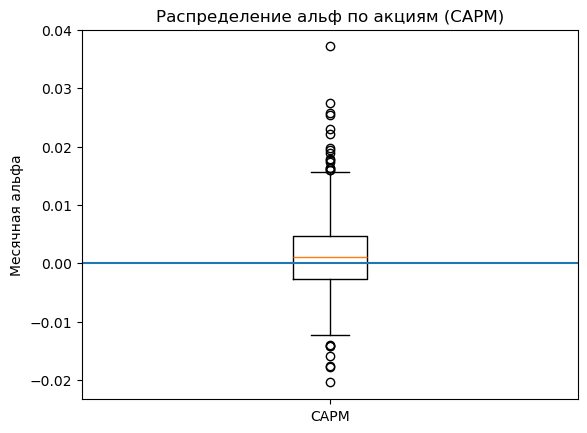

In [24]:
# Распределение альф CAPM
plt.figure()
plt.boxplot([capm_df["alpha"]], labels=["CAPM"])
plt.axhline(0.0)
plt.title("Распределение альф по акциям (CAPM)")
plt.ylabel("Месячная альфа")
plt.show()

Распределение альф CAPM сосредоточено вокруг нуля, без выраженного смещения в плюс или минус, что подтверждает отсутствие систематической недооценки или переоценки акций в рамках модели. Большинство альф по модулю невелики и укладываются в узкий диапазон, то есть устойчивых «аномальных» бумаг почти нет. Единичные выбросы с крупными альфами выглядят скорее как результат разовых событий по отдельным компаниям, а не как общерыночный эффект.

In [25]:
# Фама–Макбет: премии по факторам (без и с HAC)

print("\nФама–Макбет: средние премии факторов и t-статистики (обычные SE):")
print(lambda_summary)

# lambda_summary_hac должен быть уже посчитан в дополнительном блоке HAC
# если ещё нет — см. блок с Newey–West
print("\nФама–Макбет: средние премии факторов и t-статистики (HAC, Newey–West):")
print(lambda_summary_hac)


Фама–Макбет: средние премии факторов и t-статистики (обычные SE):
            mean_lambda    t_stat
lambda_0       0.002571  0.794870
lambda_MKT     0.009852  2.001507
lambda_SMB    -0.002377 -1.550753
lambda_HML    -0.008113 -2.558593

Фама–Макбет: средние премии факторов и t-статистики (HAC, Newey–West):
            mean_lambda    se_HAC     t_HAC
factor                                     
lambda_0       0.002571  0.003019  0.851585
lambda_MKT     0.009852  0.004586  2.148085
lambda_SMB    -0.002377  0.001343 -1.770249
lambda_HML    -0.008113  0.003575 -2.269081


Фама–Макбет с value-weighted факторами показывает устойчивую положительную премию за рыночный риск: около 1 процента в месяц, t-статистика выше 2 и в обычных, и в HAC-оценках. Премия за фактор размера отрицательная, но по модулю небольшая и по HAC-t находится на границе значимости, то есть поддержать классический small-cap эффект на этом периоде нельзя. Премия за фактор стоимости уверенно отрицательная и значима, что говорит о том, что value-акции в среднем уступали growth-компаниям. Поправка Ньюи–Уэста практически не меняет выводы, а только подтверждает их устойчивость с учётом автокорреляции во времени.

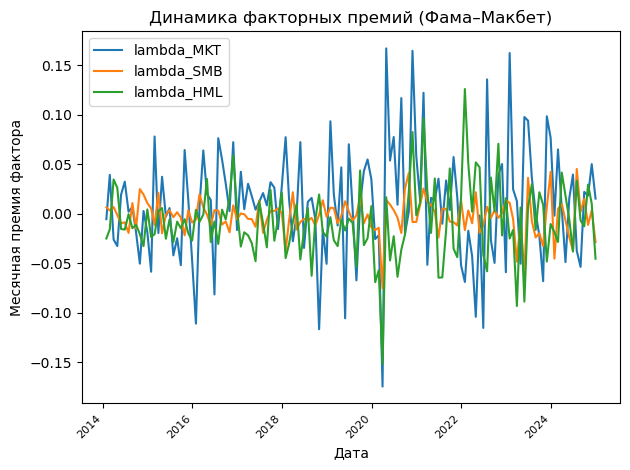

In [26]:
# Визуализация динамики и накопленных премий Фама–Макбет

plt.figure()
plt.plot(lambdas_df.index, lambdas_df["lambda_MKT"], label="lambda_MKT")
plt.plot(lambdas_df.index, lambdas_df["lambda_SMB"], label="lambda_SMB")
plt.plot(lambdas_df.index, lambdas_df["lambda_HML"], label="lambda_HML")
plt.xlabel("Дата")
plt.ylabel("Месячная премия фактора")
plt.title("Динамика факторных премий (Фама–Макбет)")
plt.legend()
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

Динамика премий показывает, что рыночный фактор на большинстве отрезков даёт положительный вклад, несмотря на сильные колебания, что согласуется с положительной средней λ_MKT. Премия за размер всё время болтается вокруг нуля, без устойчивых «плюсовых» или «минусовых» фаз, то есть размерный эффект не проявляется ни на каком промежутке. Премия по фактору стоимости часто уходит в отрицательную область, особенно в отдельные годы, что отражает систематическое отставание value-акций от growth в разные периоды, а не только в среднем по выборке.

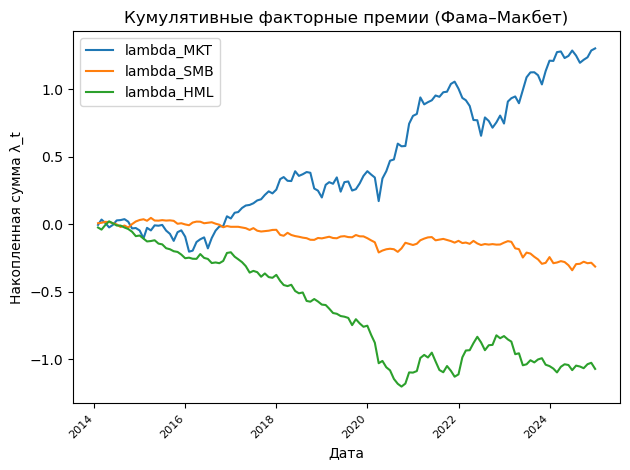

In [27]:
cum_lambdas = lambdas_df[["lambda_MKT", "lambda_SMB", "lambda_HML"]].cumsum()

plt.figure()
plt.plot(cum_lambdas.index, cum_lambdas["lambda_MKT"], label="lambda_MKT")
plt.plot(cum_lambdas.index, cum_lambdas["lambda_SMB"], label="lambda_SMB")
plt.plot(cum_lambdas.index, cum_lambdas["lambda_HML"], label="lambda_HML")
plt.xlabel("Дата")
plt.ylabel("Накопленная сумма λ_t")
plt.title("Кумулятивные факторные премии (Фама–Макбет)")
plt.legend()
plt.xticks(rotation=45, ha="right", fontsize=8)
plt.tight_layout()
plt.show()

Кумулятивные премии дают спокойную и хорошо читаемую картину. Рыночный фактор уверенно накапливает положительный результат, что подтверждает устойчивую положительную премию за рыночный риск на всём горизонте. Фактор размера остаётся около нуля, и его кумулятивная линия почти плоская, что ещё раз показывает отсутствие выраженного size-эффекта. Для фактора стоимости линия уходит глубоко в отрицательную область и сохраняет отрицательный тренд, что означает длительное систематическое отставание value-акций от growth на протяжении 2014–2024 годов.

In [28]:
# Связь бета и средней доходности (для интерпретации премий Фама–Макбет)

# Средняя избыточная доходность по акциям за период факторной выборки
mean_excess_by_stock = asset_excess.mean()

betas_returns = ff3_betas.copy()
betas_returns["mean_excess"] = mean_excess_by_stock

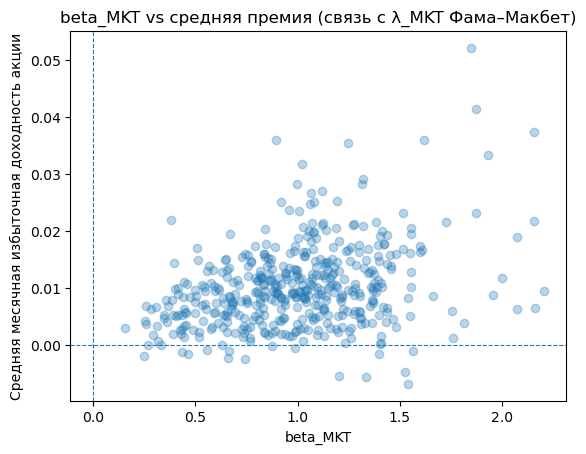

In [29]:
# beta_MKT vs средняя премия
plt.figure()
plt.scatter(betas_returns["beta_MKT"], betas_returns["mean_excess"], alpha=0.3)
plt.xlabel("beta_MKT")
plt.ylabel("Средняя месячная избыточная доходность акции")
plt.title("beta_MKT vs средняя премия (связь с λ_MKT Фама–Макбет)")
plt.axhline(0.0, linestyle="--", linewidth=0.8)
plt.axvline(0.0, linestyle="--", linewidth=0.8)
plt.show()

Зависимость между β по рынку и средней избыточной доходностью акций имеет положительный наклон, даже несмотря на шум. Это означает, что бумаги с более высокой чувствительностью к рыночным колебаниям в целом получают более высокую премию. Такой результат полностью согласуется с положительной и значимой оценкой премии λ_MKT из модели Фама–Макбет.

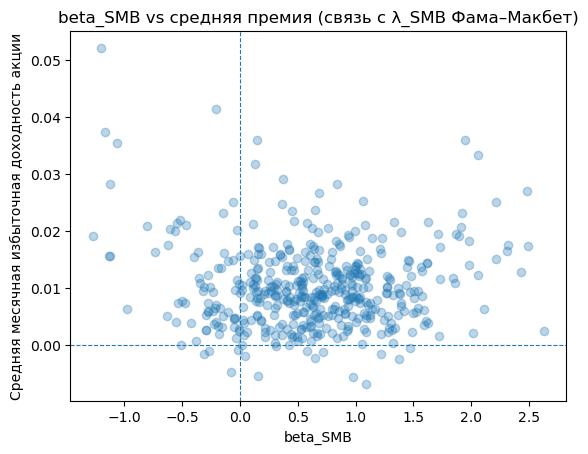

In [30]:
# beta_SMB vs средняя премия
plt.figure()
plt.scatter(betas_returns["beta_SMB"], betas_returns["mean_excess"], alpha=0.3)
plt.xlabel("beta_SMB")
plt.ylabel("Средняя месячная избыточная доходность акции")
plt.title("beta_SMB vs средняя премия (связь с λ_SMB Фама–Макбет)")
plt.axhline(0.0, linestyle="--", linewidth=0.8)
plt.axvline(0.0, linestyle="--", linewidth=0.8)
plt.show()

Зависимости между β по размеру и средней избыточной доходностью акций практически нет: точки распределены равномерно и не образуют выраженного наклона. Это подтверждает, что фактор размера не объясняет различия в доходностях на анализируемом периоде, что согласуется с малой и незначимой премией λ_SMB в модели Фама–Макбет.

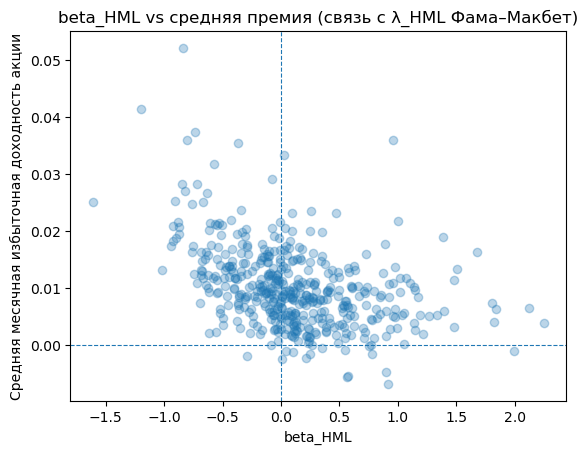

In [31]:
# beta_HML vs средняя премия
plt.figure()
plt.scatter(betas_returns["beta_HML"], betas_returns["mean_excess"], alpha=0.3)
plt.xlabel("beta_HML")
plt.ylabel("Средняя месячная избыточная доходность акции")
plt.title("beta_HML vs средняя премия (связь с λ_HML Фама–Макбет)")
plt.axhline(0.0, linestyle="--", linewidth=0.8)
plt.axvline(0.0, linestyle="--", linewidth=0.8)
plt.show()

На графике заметен устойчивый отрицательный наклон: акции с более высокой загрузкой на фактор стоимости имеют более низкую среднюю премию, а бумаги с отрицательной β_HML, то есть growth-компании, чаще зарабатывают больше. Это полностью соответствует отрицательной и значимой премии λ_HML в модели Фама–Макбет и подтверждает слабость value-эффекта на исследуемом периоде.

In [32]:
# Дополнительно: сохранение основных результатов в CSV

capm_df.to_csv("results_capm_by_stock.csv")               # альфы, беты, R2 по CAPM
ff3_df.to_csv("results_ff3_by_stock.csv")                 # альфы, беты, R2 по FF3 (для бета в Фама–Макбет)
lambdas_df.to_csv("results_ff3_fama_macbeth_lambdas.csv") # помесячные lambda_t
lambda_summary.to_csv("results_ff3_fama_macbeth_summary.csv")  # средние λ и t-статы

# Результаты по FF-портфелям сохраняем только если они были посчитаны выше
if "port_ff3_df" in globals():
    port_ff3_df.to_csv("results_ff3_by_ff_portfolios.csv")   # FF3 по 6 портфелям

if "port_premia_annual" in globals():
    port_premia_annual.to_csv(
        "results_ff_portfolios_premia_annual.csv",
        header=["annual_excess_return"]
    )

print("\nФайлы с результатами сохранены:")
print("- results_capm_by_stock.csv")
print("- results_ff3_by_stock.csv")
print("- results_ff3_fama_macbeth_lambdas.csv")
print("- results_ff3_fama_macbeth_summary.csv")
if "port_ff3_df" in globals():
    print("- results_ff3_by_ff_portfolios.csv")
if "port_premia_annual" in globals():
    print("- results_ff_portfolios_premia_annual.csv")


Файлы с результатами сохранены:
- results_capm_by_stock.csv
- results_ff3_by_stock.csv
- results_ff3_fama_macbeth_lambdas.csv
- results_ff3_fama_macbeth_summary.csv


## 6. Расширения модели: Momentum и ICAPM

Требования ТЗ предполагают:
- добавить **ICAPM** и сопоставить результаты с CAPM и Fama–French;
- (опционально) расширить факторную модель и попытаться повысить значимость/качество подгонки.

Ниже реализована четырёхфакторная модель Carhart. Она расширяет модель Фама Френч тем, что добавляет фактор моментума, который отражает эмпирическое наблюдение: акции, которые показывали высокую доходность в прошлом, часто продолжают показывать относительно высокую доходность в ближайшие месяцы, а акции с плохой прошлой динамикой чаще продолжают отставать.

Моментум в коде построен по стандартному правилу 12 2. Для каждой акции считается доходность за период примерно 12 месяцев до момента формирования, но последние 2 месяца исключаются, чтобы не смешивать моментум с краткосрочным разворотом цен. Затем акции делятся на winners и losers по значению этого показателя, и фактор MOM строится как разница доходностей портфеля winners и портфеля losers. Таким образом MOM измеряет премию за стратегию следования за трендом.

In [33]:
# тикеры акций
drop_cols = ["^GSPC", "^IRX_monthly"]
stock_tickers = [c for c in returns.columns if c not in drop_cols]

# RF и рынок
RF = returns["^IRX_monthly"]
MKT_excess = returns["^GSPC"] - RF

# Market Value (MV) по годам
mv_pivot = pd.read_csv("historical_market_cap_pivot.csv")
mv_cols = [c for c in mv_pivot.columns if c != "Ticker"]
mv_pivot[mv_cols] = mv_pivot[mv_cols].where(mv_pivot[mv_cols] > 0, np.nan)

mv_long = mv_pivot.melt(id_vars="Ticker", var_name="date", value_name="MV")
mv_long["Year"] = pd.to_datetime(mv_long["date"]).dt.year
mv_long = mv_long[["Ticker", "Year", "MV"]]

# Book Value (BV) по годам
bv_pivot = pd.read_csv("book_value_alpha_vantage_full.csv")
if "Year" not in bv_pivot.columns:
    bv_pivot = bv_pivot.rename(columns={"Unnamed: 0": "Year"})
bv_cols = [c for c in bv_pivot.columns if c != "Year"]
bv_pivot[bv_cols] = bv_pivot[bv_cols].where(bv_pivot[bv_cols] > 0, np.nan)

bv_long = bv_pivot.melt(id_vars="Year", var_name="Ticker", value_name="BE")

# fundamentals для весов и фильтрации
fundamentals = mv_long.merge(bv_long, on=["Ticker", "Year"], how="inner").dropna(subset=["MV", "BE"])
fundamentals["BM"] = fundamentals["BE"] / fundamentals["MV"]
fundamentals = fundamentals[fundamentals["BM"] > 0].copy()

mv_year_ticker = fundamentals.set_index(["Year", "Ticker"])["MV"]

# 1) Готовим сигнал momentum 12-2


ret_stocks = returns[stock_tickers].copy()

# MOM сигнал: (t-12 ... t-2), это 11 месяцев после сдвига на 2
mom_signal = (1.0 + ret_stocks).shift(2).rolling(11).apply(np.prod, raw=True) - 1.0

# 2) Весa для momentum: MV на конец предыдущего года

def get_weights_for_month(date_idx, tickers_list):
    year_t = date_idx.year - 1
    w = {}
    for tic in tickers_list:
        val = mv_year_ticker.get((year_t, tic), np.nan)
        if pd.notna(val) and val > 0:
            w[tic] = val
    if len(w) == 0:
        return None
    w = pd.Series(w)
    return w / w.sum()

# 3) Строим фактор MOM (UMD): Winners minus Losers
# Winners: топ 30%, Losers: бот 30%

mom_factor = pd.Series(index=ret_stocks.index, dtype=float)

for dt in mom_signal.index:
    sig = mom_signal.loc[dt].dropna()
    if sig.shape[0] < 50:
        continue

    p30 = np.nanpercentile(sig.values, 30)
    p70 = np.nanpercentile(sig.values, 70)

    losers = sig[sig <= p30].index.tolist()
    winners = sig[sig >= p70].index.tolist()

    w_w = get_weights_for_month(dt, winners)
    w_l = get_weights_for_month(dt, losers)
    if w_w is None or w_l is None:
        continue

    r_t = ret_stocks.loc[dt]
    r_w = (r_t[w_w.index] * w_w).sum()
    r_l = (r_t[w_l.index] * w_l).sum()

    mom_factor.loc[dt] = r_w - r_l

# 4) Строим SMB и HML (value weighted) так же, как в основном коде

# Годы формирования t: 2013–2023, держим t+1: 2014–2024
years_returns = sorted(returns.index.year.unique())
years_fund = sorted(fundamentals["Year"].unique())

formation_years = [y for y in years_fund if (y + 1) in years_returns]

memberships = {}

for t in formation_years:
    hold_year = t + 1
    df_t = fundamentals[fundamentals["Year"] == t].copy()
    df_t = df_t[df_t["Ticker"].isin(stock_tickers)]
    if df_t.empty:
        continue

    size_median = df_t["MV"].median()
    df_t["Size"] = np.where(df_t["MV"] <= size_median, "S", "B")

    p30 = np.nanpercentile(df_t["BM"], 30)
    p70 = np.nanpercentile(df_t["BM"], 70)

    def bm_grp(x):
        if x <= p30:
            return "L"
        elif x <= p70:
            return "M"
        else:
            return "H"

    df_t["BM_group"] = df_t["BM"].apply(bm_grp)

    mem = {}
    for size in ["S", "B"]:
        for bm in ["L", "M", "H"]:
            label = f"{size}{bm}"
            mem[label] = df_t[(df_t["Size"] == size) & (df_t["BM_group"] == bm)]["Ticker"].tolist()
    memberships[hold_year] = mem

# Value weighted доходности портфелей
ff_ports_vw = pd.DataFrame(index=returns.index, columns=["SL", "SM", "SH", "BL", "BM", "BH"], dtype=float)

for hold_year, mem in memberships.items():
    year_t = hold_year - 1
    df_t = fundamentals[fundamentals["Year"] == year_t].copy()
    df_t = df_t[df_t["Ticker"].isin(sum(mem.values(), []))]

    year_mask = returns.index.year == hold_year

    for label, tickers_list in mem.items():
        if len(tickers_list) == 0:
            continue
        df_port = df_t[df_t["Ticker"].isin(tickers_list)].copy()
        if df_port.empty:
            continue

        mv_vec = df_port.set_index("Ticker")["MV"].dropna()
        if mv_vec.empty:
            continue

        weights = mv_vec / mv_vec.sum()
        ret_panel = ret_stocks.loc[year_mask, weights.index]
        ff_ports_vw.loc[ret_panel.index, label] = (ret_panel * weights).sum(axis=1)

ff_ports_vw = ff_ports_vw.dropna()

SMB_vw = ff_ports_vw[["SL", "SM", "SH"]].mean(axis=1) - ff_ports_vw[["BL", "BM", "BH"]].mean(axis=1)
HML_vw = ff_ports_vw[["SH", "BH"]].mean(axis=1) - ff_ports_vw[["SL", "BL"]].mean(axis=1)

# 5) Собираем 4 фактора и делаем Фама–Макбет

factors_4f = pd.DataFrame({
    "MKT_excess": MKT_excess,
    "SMB_vw": SMB_vw,
    "HML_vw": HML_vw,
    "MOM": mom_factor,
    "RF": RF
}).dropna()

print("\nCarhart 4F доступен с", factors_4f.index.min().date(), "по", factors_4f.index.max().date())

# избыточные доходности
asset_excess_4f = returns.loc[factors_4f.index, stock_tickers].subtract(factors_4f["RF"], axis=0)

# time-series 4F для бет
def run_ts_regression_plain(y: pd.Series, X: pd.DataFrame) -> dict:
    X_const = sm.add_constant(X)
    model = sm.OLS(y, X_const, missing="drop").fit()
    out = {"alpha": model.params["const"], "t_alpha": model.tvalues["const"], "R2": model.rsquared, "n_obs": int(model.nobs)}
    for col in X.columns:
        out[f"beta_{col}"] = model.params[col]
        out[f"t_{col}"] = model.tvalues[col]
    return out

X4 = factors_4f[["MKT_excess", "SMB_vw", "HML_vw", "MOM"]]

ff4_results = {}
for tic in stock_tickers:
    ff4_results[tic] = run_ts_regression_plain(asset_excess_4f[tic], X4)

ff4_df = pd.DataFrame(ff4_results).T

ff4_betas = ff4_df[["beta_MKT_excess", "beta_SMB_vw", "beta_HML_vw", "beta_MOM"]].rename(
    columns={
        "beta_MKT_excess": "beta_MKT",
        "beta_SMB_vw": "beta_SMB",
        "beta_HML_vw": "beta_HML",
        "beta_MOM": "beta_MOM"
    }
)

# Фама–Макбет
lambdas_4f = []
for dt in factors_4f.index:
    y_t = asset_excess_4f.loc[dt].dropna()
    X_t = ff4_betas.loc[y_t.index].dropna()
    common = y_t.index.intersection(X_t.index)
    y_t = y_t.loc[common]
    X_t = X_t.loc[common]

    X_const = sm.add_constant(X_t)
    model_cs = sm.OLS(y_t.values, X_const.values).fit()

    lambdas_4f.append({
        "Date": dt,
        "lambda_0": model_cs.params[0],
        "lambda_MKT": model_cs.params[1],
        "lambda_SMB": model_cs.params[2],
        "lambda_HML": model_cs.params[3],
        "lambda_MOM": model_cs.params[4],
    })

lambdas_4f_df = pd.DataFrame(lambdas_4f).set_index("Date")

T4 = lambdas_4f_df.shape[0]
lm = lambdas_4f_df.mean()
lse = lambdas_4f_df.std(ddof=1) / np.sqrt(T4)
lt = lm / lse

lambda_4f_summary = pd.DataFrame({"mean_lambda": lm, "t_stat": lt})

print("\nФама–Макбет 4F: средние премии и t-статистики")
print(lambda_4f_summary)



Carhart 4F доступен с 2014-02-28 по 2024-12-31

Фама–Макбет 4F: средние премии и t-статистики
            mean_lambda    t_stat
lambda_0       0.000936  0.302409
lambda_MKT     0.011601  2.395793
lambda_SMB    -0.002236 -1.449344
lambda_HML    -0.007937 -2.484130
lambda_MOM     0.009351  2.161853


Фактор моментума корректно построен почти на всем периоде, но стартует позже из-за требования иметь историю доходностей для расчета моментума.

Свободный член незначим, это означает отсутствие систематического смещения модели в среднем. Премия за рыночный риск положительная и значимая, то есть рынок по прежнему платит за риск, как и в основной части. Премия за размер отрицательная, но статистически не подтверждается, значит устойчивого эффекта размера по прежнему нет. Премия за стоимость отрицательная и значима, это подтверждает вывод основной части о том, что value акции в среднем проигрывали growth. Премия по моментуму положительная и значима, это новый важный результат относительно базовой модели, он говорит о том, что фактор моментума действительно добавляет объясняющую силу и отражает отдельный источник доходности.

Для ICAPM дополнительно из базы FRED были выгружены два месячных макро ряда за период 2014–2024: доходность 10 летних казначейских облигаций США и кредитный спред, рассчитанный как разница между доходностью корпоративных облигаций рейтинга Baa и доходностью 10 летних казначейских облигаций. Эти два ряда отражают изменения условий на финансовом рынке и инвестиционных возможностей, поэтому в ICAPM они используются как переменные состояния.

Далее эти макро данные были приведены к месячной частоте и переведены из процентов в доли. В модель ICAPM включались не сами уровни ставок и спреда, а их инновации, то есть неожиданная часть изменений, рассчитанная как остатки авторегрессии первого порядка. Таким образом ICAPM в коде проверяет, получают ли акции премию за риск, связанный с неожиданными изменениями долгосрочной ставки и кредитных условий, в дополнение к рыночному риску.

In [34]:
# ICAPM с использованием FRED факторов (10Y и кредитный спред)
# Важно: значения из FRED в процентах, поэтому делим на 100
# Важно: в ICAPM используем инновации (остатки AR(1)), а не уровни

# Данные по акциям и рынку
returns = pd.read_csv("monthly_returns_2013-2024.csv", parse_dates=["Date"]).set_index("Date")

drop_cols = ["^GSPC", "^IRX_monthly"]
stock_tickers = [c for c in returns.columns if c not in drop_cols]

RF = returns["^IRX_monthly"]
MKT_excess = returns["^GSPC"] - RF

# Данные FRED (месячные, 2014-01 - 2024-12)
fred = pd.read_csv("fred_state_variables_monthly_2014_2024.csv", parse_dates=["Date"]).set_index("Date")

# переводим проценты в доли
fred = fred / 100.0

# длинная ставка и кредитные условия
teny = fred["10Y_Treasury_yield_percent"].rename("teny")
baa10y = fred["Baa_minus_10Y_spread_percent"].rename("baa10y")

state = pd.DataFrame({
    "teny": teny,
    "baa10y": baa10y
}).dropna()

# Инновации state variables через AR(1) остатки
def ar1_innovation(s: pd.Series) -> pd.Series:
    s = s.dropna()
    y = s.iloc[1:].values
    X = sm.add_constant(s.iloc[:-1].values)
    fit = sm.OLS(y, X).fit()
    resid = fit.resid
    return pd.Series(resid, index=s.index[1:])

teny_innov = ar1_innovation(state["teny"])
baa10y_innov = ar1_innovation(state["baa10y"])

icapm_factors = pd.DataFrame(index=state.index)
icapm_factors["MKT_excess"] = MKT_excess.loc[state.index]
icapm_factors["RF"] = RF.loc[state.index]
icapm_factors["TENY_innov"] = teny_innov
icapm_factors["CREDIT_innov"] = baa10y_innov
icapm_factors = icapm_factors.dropna()

print("\nICAPM факторы доступны с", icapm_factors.index.min().date(), "по", icapm_factors.index.max().date())

# Избыточные доходности под период ICAPM
asset_excess_icapm = returns.loc[icapm_factors.index, stock_tickers].subtract(icapm_factors["RF"], axis=0)

# Time-series ICAPM для бет
def run_ts_regression_plain(y: pd.Series, X: pd.DataFrame) -> dict:
    X_const = sm.add_constant(X)
    model = sm.OLS(y, X_const, missing="drop").fit()
    out = {
        "alpha": model.params["const"],
        "t_alpha": model.tvalues["const"],
        "R2": model.rsquared,
        "n_obs": int(model.nobs),
    }
    for col in X.columns:
        out[f"beta_{col}"] = model.params[col]
        out[f"t_{col}"] = model.tvalues[col]
    return out

X_icapm = icapm_factors[["MKT_excess", "TENY_innov", "CREDIT_innov"]]

icapm_results = {}
for tic in stock_tickers:
    icapm_results[tic] = run_ts_regression_plain(asset_excess_icapm[tic], X_icapm)

icapm_df = pd.DataFrame(icapm_results).T

icapm_betas = icapm_df[["beta_MKT_excess", "beta_TENY_innov", "beta_CREDIT_innov"]].rename(
    columns={
        "beta_MKT_excess": "beta_MKT",
        "beta_TENY_innov": "beta_TENY",
        "beta_CREDIT_innov": "beta_CREDIT"
    }
)

print("\nПример ICAPM результатов:")
print(icapm_df.head())

# Фама–Макбет ICAPM: премии по рынку и инновациям состояния
lambdas_icapm = []

for dt in icapm_factors.index:
    y_t = asset_excess_icapm.loc[dt].dropna()
    X_t = icapm_betas.loc[y_t.index].dropna()

    common = y_t.index.intersection(X_t.index)
    y_t = y_t.loc[common]
    X_t = X_t.loc[common]

    X_const = sm.add_constant(X_t)
    model_cs = sm.OLS(y_t.values, X_const.values).fit()

    lambdas_icapm.append({
        "Date": dt,
        "lambda_0": model_cs.params[0],
        "lambda_MKT": model_cs.params[1],
        "lambda_TENY": model_cs.params[2],
        "lambda_CREDIT": model_cs.params[3],
    })

lambdas_icapm_df = pd.DataFrame(lambdas_icapm).set_index("Date")

Ti = lambdas_icapm_df.shape[0]
lm_i = lambdas_icapm_df.mean()
lse_i = lambdas_icapm_df.std(ddof=1) / np.sqrt(Ti)
lt_i = lm_i / lse_i

lambda_icapm_summary = pd.DataFrame({"mean_lambda": lm_i, "t_stat": lt_i})

print("\nФама–Макбет ICAPM: средние премии и t-статистики")
print(lambda_icapm_summary)


ICAPM факторы доступны с 2014-02-28 по 2024-12-31

Пример ICAPM результатов:
         alpha   t_alpha        R2  n_obs  beta_MKT_excess  t_MKT_excess  \
A    -0.000776 -0.176956  0.527160  131.0         1.231555      9.290590   
AAPL  0.010573  2.039210  0.470317  131.0         1.307816      8.339429   
ABBV  0.004209  0.694300  0.183938  131.0         0.784197      4.277346   
ABT   0.001014  0.255364  0.416109  131.0         0.895739      7.461008   
ACGL  0.008090  1.471039  0.214561  131.0         0.621342      3.735483   

      beta_TENY_innov  t_TENY_innov  beta_CREDIT_innov  t_CREDIT_innov  
A           -1.936253     -0.924486           3.086245        1.025966  
AAPL        -1.999878     -0.807127           3.601280        1.011951  
ABBV         4.057333      1.400680           1.694334        0.407251  
ABT         -1.238163     -0.652744           2.304756        0.845969  
ACGL         5.916942      2.251448          -2.154882       -0.570890  

Фама–Макбет ICAPM: средние

Модель подтверждает, что на рынке сохраняется устойчивая премия за общий рыночный риск. Дополнительные межвременные факторы, связанные с изменениями процентных ставок и кредитных условий, в среднем не получают устойчивой премии на рассматриваемом периоде. Для отдельных компаний чувствительность к этим изменениям может быть заметной, но на уровне всей выборки это не превращается в систематический источник доходности. В целом межвременная спецификация не даёт явного улучшения по сравнению с базовой факторной моделью. Основная часть объяснения доходностей по прежнему связана с рыночным компонентом.

In [35]:
ff4_df.to_csv("results_ff4_by_stock.csv")
lambdas_4f_df.to_csv("results_ff4_fama_macbeth_lambdas.csv")
lambda_4f_summary.to_csv("results_ff4_fama_macbeth_summary.csv")
factors_4f.to_csv("factors_4f_value_weighted.csv")

icapm_df.to_csv("results_icapm_by_stock.csv")
lambdas_icapm_df.to_csv("results_icapm_fama_macbeth_lambdas.csv")
lambda_icapm_summary.to_csv("results_icapm_fama_macbeth_summary.csv")
icapm_factors.to_csv("icapm_state_factors.csv")

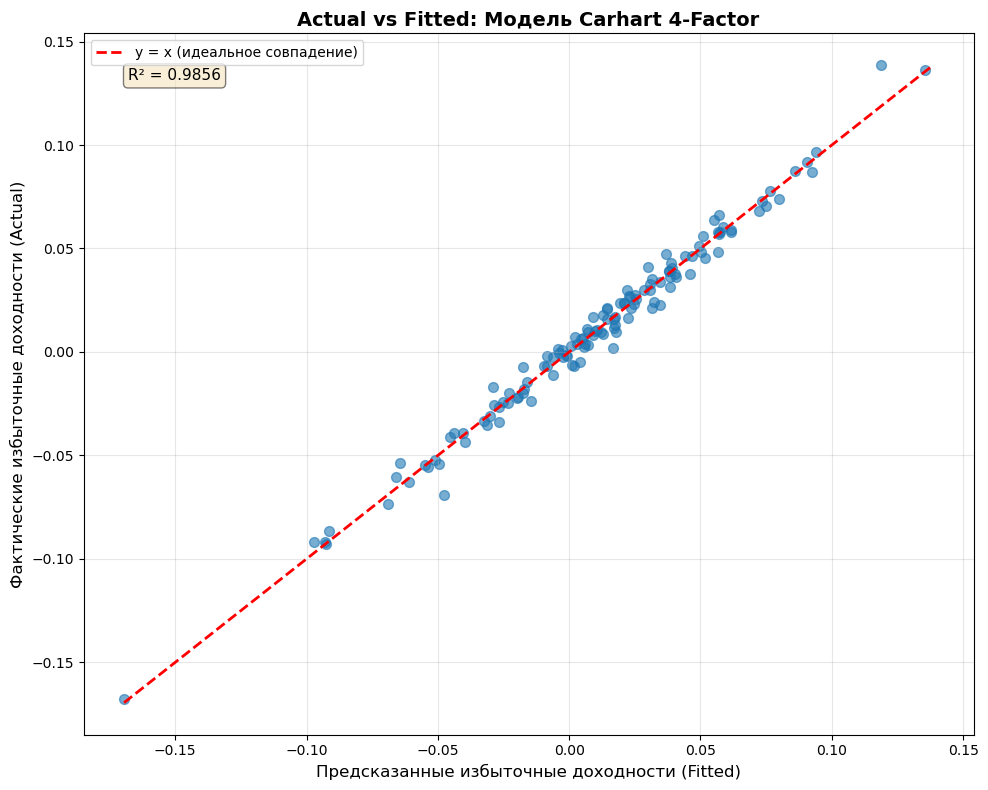


Статистика модели Carhart 4F:
                            OLS Regression Results                            
Dep. Variable:          excess_return   R-squared:                       0.986
Model:                            OLS   Adj. R-squared:                  0.985
Method:                 Least Squares   F-statistic:                     2163.
Date:                Sat, 20 Dec 2025   Prob (F-statistic):          4.88e-115
Time:                        14:05:08   Log-Likelihood:                 496.20
No. Observations:                 131   AIC:                            -982.4
Df Residuals:                     126   BIC:                            -968.0
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0015

In [36]:
# Scatter-график "Actual vs Fitted" для модели Carhart 4F

# Загрузка данных из файла factors_4f_value_weighted.csv
factors_4f_data = pd.read_csv("factors_4f_value_weighted.csv", parse_dates=["Date"])
factors_4f_data.set_index("Date", inplace=True)

# Приведение даты к формату datetime (уже сделано при загрузке)
# factors_4f_data.index уже в формате datetime после parse_dates и set_index

# Расчет доходности портфеля
# Если в файле есть столбец с доходностью портфеля, используем его
# Иначе используем равновзвешенный портфель всех акций
if "Portfolio_return" in factors_4f_data.columns:
    portfolio_return = factors_4f_data["Portfolio_return"]
else:
    # Загружаем данные по доходностям акций для расчета равновзвешенного портфеля
    returns_data = pd.read_csv("monthly_returns_2013-2024.csv", parse_dates=["Date"])
    returns_data.set_index("Date", inplace=True)
    
    # Тикеры акций (без индекса и безрисковой ставки)
    drop_cols = ["^GSPC", "^IRX_monthly"]
    stock_tickers_port = [c for c in returns_data.columns if c not in drop_cols]
    
    # Выравниваем индексы
    common_dates = factors_4f_data.index.intersection(returns_data.index)
    returns_aligned = returns_data.loc[common_dates, stock_tickers_port]
    
    # Равновзвешенный портфель: средняя доходность по всем акциям
    portfolio_return = returns_aligned.mean(axis=1)
    
    # Выравниваем индексы с factors_4f_data
    portfolio_return = portfolio_return.reindex(factors_4f_data.index)

# Расчет избыточной доходности портфеля
portfolio_excess = portfolio_return - factors_4f_data["RF"]

# Удаление наблюдений с пропущенными значениями
# Создаем DataFrame для регрессии
regression_data = pd.DataFrame({
    "excess_return": portfolio_excess,
    "MKT_excess": factors_4f_data["MKT_excess"],
    "SMB_vw": factors_4f_data["SMB_vw"],
    "HML_vw": factors_4f_data["HML_vw"],
    "MOM": factors_4f_data["MOM"]
})

# Удаляем строки с пропущенными значениями
regression_data = regression_data.dropna()

# Оценка многофакторной линейной регрессии Carhart 4F методом наименьших квадратов
y = regression_data["excess_return"]
X = regression_data[["MKT_excess", "SMB_vw", "HML_vw", "MOM"]]

# Добавляем константу
X_const = sm.add_constant(X)

# Оценка модели
model = sm.OLS(y, X_const, missing="drop").fit()

# Расчет предсказанных (fitted) значений доходности
fitted_values = model.fittedvalues
actual_values = y

# Построение scatter-графика "Actual vs Fitted"
plt.figure(figsize=(10, 8))
plt.scatter(fitted_values, actual_values, alpha=0.6, s=50)

# Линия под углом 45 градусов (y = x) для идеального совпадения
min_val = min(fitted_values.min(), actual_values.min())
max_val = max(fitted_values.max(), actual_values.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', linewidth=2, label='y = x (идеальное совпадение)')

# Подписи осей и заголовок
plt.xlabel("Предсказанные избыточные доходности (Fitted)", fontsize=12)
plt.ylabel("Фактические избыточные доходности (Actual)", fontsize=12)
plt.title("Actual vs Fitted: Модель Carhart 4-Factor", fontsize=14, fontweight='bold')

# Добавляем легенду
plt.legend(fontsize=10)

# Добавляем сетку для лучшей читаемости
plt.grid(True, alpha=0.3)

# Добавляем информацию о качестве модели в заголовок или как текст
r_squared = model.rsquared
plt.text(0.05, 0.95, f'R² = {r_squared:.4f}', transform=plt.gca().transAxes, 
         fontsize=11, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.show()

# Вывод статистики модели
print("\nСтатистика модели Carhart 4F:")
print(model.summary())



График сохранен в файл: cum_mom_factor.png


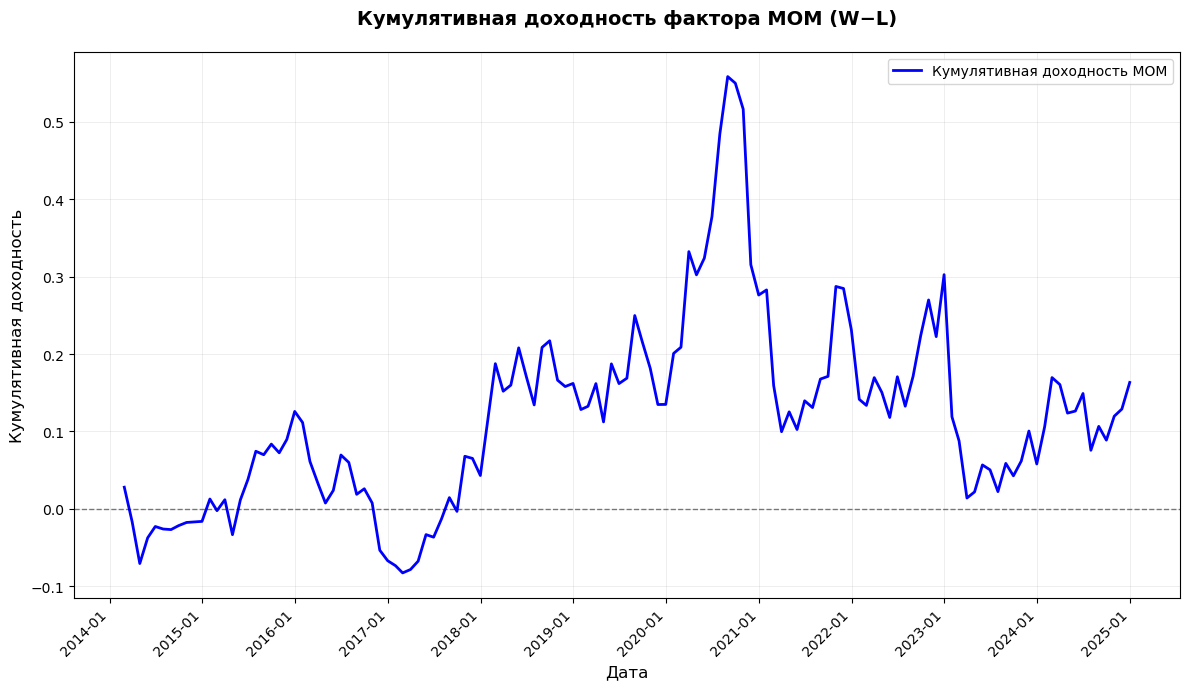


Статистика фактора MOM:
Период: 2014-02-28 - 2024-12-31
Количество наблюдений: 131
Средняя месячная доходность: 0.001964 (0.1964%)
Стандартное отклонение: 0.040119 (4.0119%)
Итоговая кумулятивная доходность: 0.163368 (16.34%)


In [37]:
# График кумулятивной доходности фактора моментума MOM (W−L)

import matplotlib.dates as mdates

# Загружаем фактор MOM из файла factors_4f_value_weighted.csv
# или используем mom_factor, если он доступен в памяти
if 'mom_factor' in globals():
    mom_factor_series = mom_factor.copy()
else:
    # Загружаем из файла
    factors_4f_data = pd.read_csv("factors_4f_value_weighted.csv", parse_dates=["Date"])
    factors_4f_data.set_index("Date", inplace=True)
    mom_factor_series = factors_4f_data["MOM"].copy()

# Приведение индекса к типу datetime и сортировка по времени
if not isinstance(mom_factor_series.index, pd.DatetimeIndex):
    mom_factor_series.index = pd.to_datetime(mom_factor_series.index)
mom_factor_series = mom_factor_series.sort_index()

# Удаление пропусков (NaN)
mom_factor_series = mom_factor_series.dropna()

# Проверка и преобразование: если значения в процентах (> 1 по модулю), делим на 100
if mom_factor_series.abs().max() > 1:
    print("Внимание: значения выглядят как проценты, преобразуем в доли")
    mom_factor_series = mom_factor_series / 100.0

# Расчет кумулятивной доходности фактора как накопленный продукт
cum_mom = (1 + mom_factor_series).cumprod() - 1

# Построение линейного графика
plt.figure(figsize=(12, 7))
plt.plot(cum_mom.index, cum_mom.values, linewidth=2, color='blue', label='Кумулятивная доходность MOM')

# Горизонтальная линия на уровне 0
plt.axhline(y=0, color='black', linestyle='--', linewidth=1, alpha=0.5)

# Заголовок и подписи осей
plt.title("Кумулятивная доходность фактора MOM (W−L)", fontsize=14, fontweight='bold', pad=20)
plt.xlabel("Дата", fontsize=12)
plt.ylabel("Кумулятивная доходность", fontsize=12)

# Форматирование дат на оси X (год-месяц)
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%Y-%m'))
plt.gca().xaxis.set_major_locator(mdates.YearLocator())
plt.xticks(rotation=45, ha='right')

# Добавление сетки
plt.grid(True, alpha=0.3, linestyle='-', linewidth=0.5)

# Добавление легенды
plt.legend(loc='best', fontsize=10)

# Плотный layout
plt.tight_layout()

# Сохранение графика в файл
plt.savefig("cum_mom_factor.png", dpi=300, bbox_inches='tight')
print("\nГрафик сохранен в файл: cum_mom_factor.png")

# Вывод графика на экран
plt.show()

# Вывод статистики
print(f"\nСтатистика фактора MOM:")
print(f"Период: {cum_mom.index.min().strftime('%Y-%m-%d')} - {cum_mom.index.max().strftime('%Y-%m-%d')}")
print(f"Количество наблюдений: {len(mom_factor_series)}")
print(f"Средняя месячная доходность: {mom_factor_series.mean():.6f} ({mom_factor_series.mean()*100:.4f}%)")
print(f"Стандартное отклонение: {mom_factor_series.std():.6f} ({mom_factor_series.std()*100:.4f}%)")
print(f"Итоговая кумулятивная доходность: {cum_mom.iloc[-1]:.6f} ({cum_mom.iloc[-1]*100:.2f}%)")
